# Dusty Red Galaxies in COSMOS-Web
AP 2026

In [1]:
%load_ext autoreload
%autoreload 2

In [34]:
# imports
import numpy as np
import matplotlib.pyplot as plt
from utilities.cosmosWebHandler import CosmosWebHandler

from astropy.table import Table
from utilities.almaHandler import AlmaHandler
from utilities.mighteeHandler import MighteeHandler
from utilities.superDeblendedHandler import SuperDeblendedHandler

In [214]:
# constants
CATALOG_PATH = "/Volumes/Apple SDXC Reader Media/dusty-red/data/COSMOSWeb_mastercatalog_v1.1.fits"

DATA_DIR    = '/Volumes/Apple SDXC Reader Media/dusty-red/data'   # folder with the tiles
# (old) only needed if viewing the tile images of the catalog objects

ALMA_PRELIM_PRIOR_CATALOG = '/Volumes/Apple SDXC Reader Media/dusty-red/data/alma_prelim_catalog/Catalogs/champs_prior_catalog.fits'
ALMA_PRELIM_BLIND_CATALOG = '/Volumes/Apple SDXC Reader Media/dusty-red/data/alma_prelim_catalog/Catalogs/champs_blind_catalog.fits'
ALMA_IMAGE_MAP40 = '/Volumes/Apple SDXC Reader Media/dusty-red/data/alma_prelim_catalog/image_maps/champs_full_field_concat_split_pbcorr_40.fits'
ALMA_IMAGE_MAP20 = '/Volumes/Apple SDXC Reader Media/dusty-red/data/alma_prelim_catalog/image_maps/champs_full_field_concat_split_pbcorr_20.fits'
ALMA_IMAGE_MAP = '/Volumes/Apple SDXC Reader Media/dusty-red/data/alma_prelim_catalog/image_maps/champs_full_field_concat_split_image.fits'

MIGHTEE_CATALOG = '/Volumes/Apple SDXC Reader Media/dusty-red/data/mightee_continuum/MIGHTEE_Continuum_DR1_COSMOS_5p2arcsec_I_v1.1.fits'

SUPER_DEBLENDED_CATALOG = '/Volumes/Apple SDXC Reader Media/dusty-red/data/super-deblended/COSMOS_deblended_FIR_201821_photo_phys_2023June.fits'

In [4]:
# load the handler
cosmosWebHandler = CosmosWebHandler(CATALOG_PATH)
cosmosWebHandler.load_catalog()

Filename: /Volumes/Apple SDXC Reader Media/dusty-red/data/COSMOSWeb_mastercatalog_v1.1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  PHOTOMETRY HOTCOLD AND SE++    1 BinTableHDU    603   784016R x 287C   [K, K, 3A, K, D, D, D, D, D, D, D, D, D, 4A, D, D, D, D, D, 5D, 5D, 5D, D, D, D, D, D, 5D, 5D, 5D, D, D, D, D, D, 5D, 5D, 5D, D, D, D, D, D, 5D, 5D, 5D, D, D, D, D, D, 5D, 5D, 5D, D, D, D, D, D, 5D, 5D, 5D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, L, L, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, K, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D,

### sanity checks

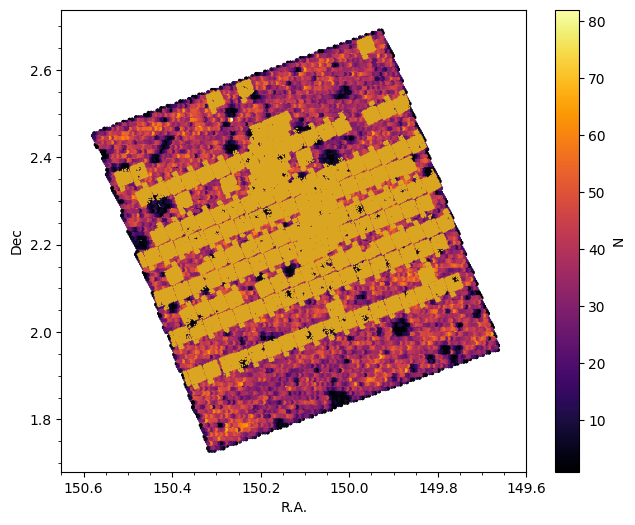

In [ ]:
# test, plot miri
fig, ax = plt.subplots(1,1, figsize=(7.5, 6))

ax.hexbin(cosmosWebHandler.get_cat_photom()['ra'], cosmosWebHandler.get_cat_photom()['dec'], gridsize=160, cmap='gray', mincnt=1)

hb = ax.hexbin(cosmosWebHandler.get_cat_photom('condition_clean')['ra'], cosmosWebHandler.get_cat_photom('condition_clean')['dec'], gridsize=160, cmap='inferno', mincnt=1)

ax.plot(cosmosWebHandler.get_cat_photom('condition_clean_miri')['ra'], cosmosWebHandler.get_cat_photom('condition_clean_miri')['dec'], 'o', ms=1.0, markeredgecolor='None', alpha=1, color='goldenrod')

cb = fig.colorbar(hb, ax=ax)
cb.set_label('N')
ax.set_xlabel('R.A.')
ax.set_ylabel('Dec')
ax.set_xlim(150.65, 149.6)
ax.minorticks_on()

## make detection cuts

#### condition non_detection

Filter cut: 193344 out of 193362 objects remain. Fraction: 99.99%


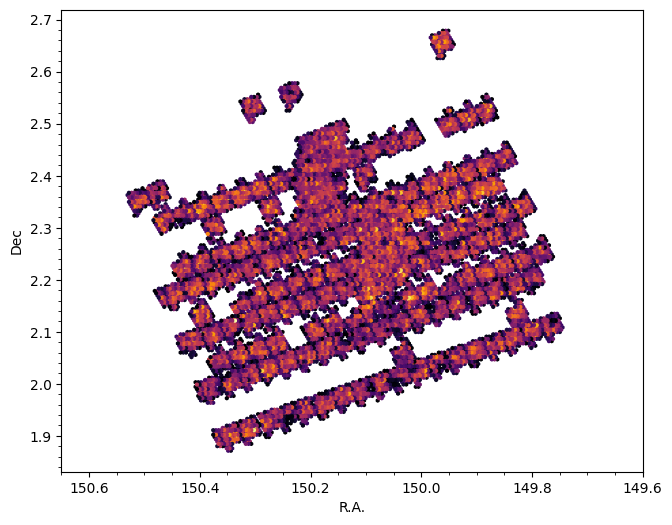

In [5]:
# make selection:
# S/N<3 for non-detection flux_model_f115w/flux_err-cal_model_f115w < 3 

condition_non_detection = cosmosWebHandler.get_filter_cut(filtername='condition_non_detection', filter_func=lambda photom, lephare, cigale, bd: (photom['flux_model_f277w']/photom['flux_err-cal_model_f277w'] >= 3) | (photom['flux_model_f115w']/photom['flux_err-cal_model_f115w'] >= 3) | (photom['flux_model_f150w']/photom['flux_err-cal_model_f150w'] >= 3) | (photom['flux_model_f444w']/photom['flux_err-cal_model_f444w'] < 5) | (photom['flux_model_f770w']/photom['flux_err-cal_model_f770w'] < 5))

#plot the non-detections
figNonDetection, axNonDetection = plt.subplots(1,1, figsize=(7.5, 6))

axNonDetection.hexbin(cosmosWebHandler.get_cat_photom('condition_non_detection')['ra'], cosmosWebHandler.get_cat_photom('condition_non_detection')['dec'], gridsize=160, cmap='inferno', mincnt=1)

axNonDetection.set_xlabel('R.A.')
axNonDetection.set_ylabel('Dec')
axNonDetection.set_xlim(150.65, 149.6)
axNonDetection.minorticks_on()



#### condition detection – flux model

Filter cut: 18 out of 193362 objects remain. Fraction: 0.01%


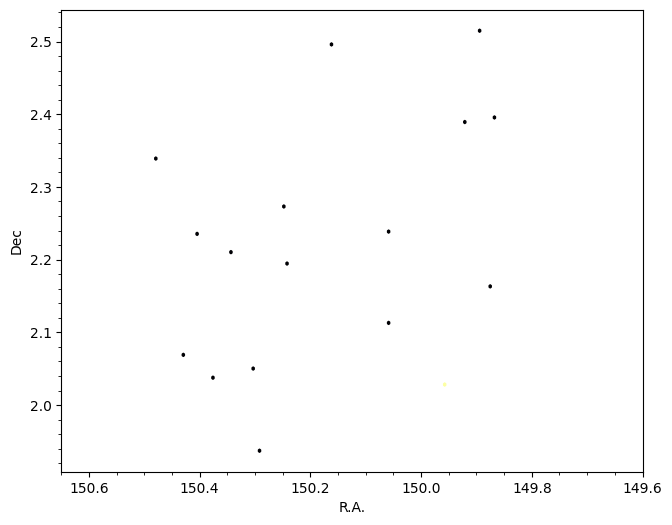

In [6]:

condition_detection = cosmosWebHandler.get_filter_cut(filtername='condition_detection', filter_func=lambda photom, lephare, cigale, bd: (photom['flux_model_f277w']/photom['flux_err-cal_model_f277w'] < 3) & (photom['flux_model_f115w']/photom['flux_err-cal_model_f115w'] < 3) & (photom['flux_model_f150w']/photom['flux_err-cal_model_f150w'] < 3) & (photom['flux_model_f444w']/photom['flux_err-cal_model_f444w'] >= 5) & (photom['flux_model_f770w']/photom['flux_err-cal_model_f770w'] >= 5))
                                                                                                                                                                                                                

figDetection, axDetection = plt.subplots(1,1, figsize=(7.5, 6))
axDetection.hexbin(cosmosWebHandler.get_cat_photom('condition_detection')['ra'], cosmosWebHandler.get_cat_photom('condition_detection')['dec'], gridsize=160, cmap='inferno', mincnt=1)

axDetection.set_xlabel('R.A.')
axDetection.set_ylabel('Dec')

axDetection.set_xlim(150.65, 149.6)
axDetection.minorticks_on()


#### condition detection -- flux aperature

Filter cut: 29 out of 193362 objects remain. Fraction: 0.01%


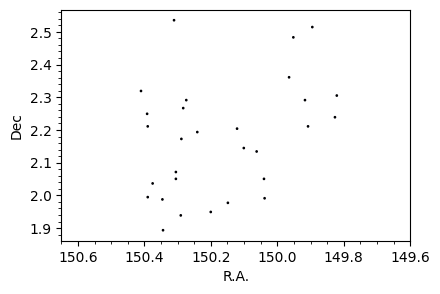

In [215]:
condition_detection_aper = cosmosWebHandler.get_filter_cut(
    filtername='condition_detection_aper',
    filter_func=lambda photom, lephare, cigale, bd: (
        (np.asarray(photom['flux_aper_f277w'])[:, 2] / np.asarray(photom['flux_err_aper_f277w'])[:, 2] < 3)
        & (np.asarray(photom['flux_aper_f115w'])[:, 2] / np.asarray(photom['flux_err_aper_f115w'])[:, 2] < 3)
        & (np.asarray(photom['flux_aper_f150w'])[:, 2] / np.asarray(photom['flux_err_aper_f150w'])[:, 2] < 3)
        & (np.asarray(photom['flux_aper_f444w'])[:, 2] / np.asarray(photom['flux_err_aper_f444w'])[:, 2] >= 5)
        & (np.asarray(photom['flux_aper_f770w'])[:, 2] / np.asarray(photom['flux_err_aper_f770w'])[:, 2] >= 5)
    )
)
                                                                                                                                                                                                                

figDetection, axDetection = plt.subplots(1,1, figsize=(4.5, 3))
axDetection.hexbin(cosmosWebHandler.get_cat_photom('condition_detection_aper')['ra'], cosmosWebHandler.get_cat_photom('condition_detection_aper')['dec'], gridsize=160, cmap='inferno', mincnt=1)

axDetection.set_xlabel('R.A.')
axDetection.set_ylabel('Dec')

axDetection.set_xlim(150.65, 149.6)
axDetection.minorticks_on()


### see detection images from tile

In [30]:
# get the tiles the 18 detected objects are in, and plot them as an interactive plot so that we can cycle through them
cat_photom_condition_detection = cosmosWebHandler.get_cat_photom('condition_detection')
cat_photom_condition_detection['tile']
print(np.unique(cat_photom_condition_detection['tile']))

['A1' 'A10' 'A3' 'A5' 'A7' 'B1' 'B10' 'B3' 'B5' 'B6' 'B7' 'B9']


In [ ]:
# visualize the 18 detected objects: detection map + f115w/f150w/f444w/f770w
# cutouts side by side, cycled with ipywidgets.
#
# Detection tiles (detection_chi2pos_SWLW_<TILE>.fits) are single-channel chi^2
# maps. The per-band panels use COSMOS-Web DR1 mosaics (cosmos2025.iap.fr),
# naming:  mosaic_nircam_f115w_COSMOS-Web_30mas_A1_v1.0_sci.fits[.gz]
# Any band whose file is not found renders as a "missing" placeholder.

import os
import ipywidgets as widgets
from IPython.display import display
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
from astropy.nddata import Cutout2D
from astropy.io import fits
from astropy.visualization import ImageNormalize, ZScaleInterval, AsinhStretch
import astropy.units as u

CUTOUT_SIZE = 3.0 * u.arcsec                                      # box size on a side
PIXSCALE    = '30mas'                                             # '30mas' or '60mas'
EXT         = '.fits'                                             # '.fits.gz' if kept gzipped

# Ordered panels: (label, filename template). {tile} is filled per object;
# templates without {tile} are treated as a single mosaic for all objects.
PANELS = [
    ('detection', 'detection_chi2pos_SWLW_{tile}.fits'),
    ('f115w', f'mosaic_nircam_f115w_COSMOS-Web_{PIXSCALE}_{{tile}}_v1.0_sci{EXT}'),
    ('f150w', f'mosaic_nircam_f150w_COSMOS-Web_{PIXSCALE}_{{tile}}_v1.0_sci{EXT}'),
    ('f444w', f'mosaic_nircam_f444w_COSMOS-Web_{PIXSCALE}_{{tile}}_v1.0_sci{EXT}'),
    ('f770w', f'mosaic_miri_f770w_COSMOS-Web_{PIXSCALE}_{{tile}}_v1.0_sci{EXT}'),  # MIRI: verify exact name
]

_cat = cosmosWebHandler.get_cat_photom('condition_detection')
_ra, _dec = np.asarray(_cat['ra']), np.asarray(_cat['dec'])
_tile = np.asarray(_cat['tile']).astype(str)
_ids = np.asarray(_cat['id']) if 'id' in _cat.colnames else np.arange(len(_cat))
_n = len(_cat)


def _img_hdu(hdul):
    """Return (data, header) for the first HDU holding a 2-D image."""
    for h in hdul:
        if h.data is not None and h.data.ndim == 2:
            return h.data, h.header
    raise ValueError("No 2-D image HDU found.")


_cache = {}   # (label, tile) -> (data memmap, wcs) or None if file absent

def _load(label, template, tile):
    key = (label, tile)
    if key not in _cache:
        path = os.path.join(DATA_DIR, template.format(tile=tile))
        if os.path.exists(path):
            data, hdr = _img_hdu(fits.open(path, memmap=True))
            _cache[key] = (data, WCS(hdr))
        else:
            _cache[key] = None
    return _cache[key]


def _draw_panel(ax, label, template, ra, dec, tile):
    loaded = _load(label, template, tile)
    if loaded is None:
        ax.text(0.5, 0.5, f"{label}\n(missing)", ha='center', va='center', fontsize=9)
        ax.set_axis_off()
        return
    data, wcs = loaded
    pos = SkyCoord(ra, dec, unit='deg')
    scale = np.abs(wcs.proj_plane_pixel_scales()[0].to(u.arcsec))
    npix = int(round((CUTOUT_SIZE / scale).decompose().value))
    stamp = Cutout2D(data, pos, npix, wcs=wcs, mode='partial', fill_value=0.0).data
    norm = ImageNormalize(stamp, interval=ZScaleInterval(), stretch=AsinhStretch())
    ax.imshow(stamp, origin='lower', cmap='gray', norm=norm)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(label, fontsize=10)


_slider = widgets.IntSlider(min=0, max=_n - 1, step=1, value=0, description='object')
_prev = widgets.Button(description='◀ Prev')
_next = widgets.Button(description='Next ▶')
_out = widgets.Output()


def _show(i):
    with _out:
        _out.clear_output(wait=True)
        fig, axes = plt.subplots(1, len(PANELS), figsize=(3.2 * len(PANELS), 3.4))
        for ax, (label, template) in zip(np.atleast_1d(axes), PANELS):
            _draw_panel(ax, label, template, _ra[i], _dec[i], _tile[i])
        fig.suptitle(f"[{i + 1}/{_n}]  id={_ids[i]}  tile {_tile[i]}  "
                     f"RA={_ra[i]:.5f}  Dec={_dec[i]:.5f}", fontsize=11)
        fig.tight_layout()
        plt.show()


_slider.observe(lambda change: _show(change['new']), names='value')
_prev.on_click(lambda _: setattr(_slider, 'value', max(0, _slider.value - 1)))
_next.on_click(lambda _: setattr(_slider, 'value', min(_n - 1, _slider.value + 1)))

display(widgets.HBox([_prev, _slider, _next]), _out)
_show(_slider.value)   # render the first object immediately


### see detection from inspection plots

#### condition detection -- flux model

In [7]:
# cycle through the 18 detected objects, showing the COSMOS-Web DR1 per-source
# inspection plot (SED) for each via "https://cosmos2025.iap.fr/fitsmap/data/inspec_plots/cosmos_web_sed_{sid}.pdf"
import requests
import fitz  # PyMuPDF
from IPython.display import Image, display
import ipywidgets as widgets

pdf_url_sourceid = lambda sid: f"https://cosmos2025.iap.fr/fitsmap/data/inspec_plots/cosmos_web_sed_{sid}.pdf"

_cat_sed = cosmosWebHandler.get_cat_photom('condition_detection')
_sids = np.asarray(_cat_sed['id'])
_tiles_sed = np.asarray(_cat_sed['tile']).astype(str)
_n_sed = len(_sids)

_png_cache = {}   # sid -> list of PNG byte-strings (one per page)

def _render_pdf(sid, dpi=130):
    if sid not in _png_cache:
        r = requests.get(pdf_url_sourceid(sid), timeout=30)
        r.raise_for_status()
        doc = fitz.open(stream=r.content, filetype='pdf')
        _png_cache[sid] = [doc.load_page(p).get_pixmap(dpi=dpi).tobytes('png')
                           for p in range(doc.page_count)]
        doc.close()
    return _png_cache[sid]


_slider_sed = widgets.IntSlider(min=0, max=_n_sed - 1, step=1, value=0, description='object')
_prev_sed = widgets.Button(description='◀ Prev')
_next_sed = widgets.Button(description='Next ▶')
_out_sed = widgets.Output()


def _show_sed(i):
    with _out_sed:
        _out_sed.clear_output(wait=True)
        sid = int(_sids[i])
        print(f"[{i + 1}/{_n_sed}]  id={sid}  tile {_tiles_sed[i]}")
        if fitz is None:
            print("Install PyMuPDF to render the inspection plots:  pip install pymupdf")
            print("Direct link:", pdf_url_sourceid(sid))
            return
        try:
            for png in _render_pdf(sid):
                display(Image(data=png))
        except Exception as e:
            print(f"Could not load plot for id={sid}: {e}")
            print("Direct link:", pdf_url_sourceid(sid))


_slider_sed.observe(lambda change: _show_sed(change['new']), names='value')
_prev_sed.on_click(lambda _: setattr(_slider_sed, 'value', max(0, _slider_sed.value - 1)))
_next_sed.on_click(lambda _: setattr(_slider_sed, 'value', min(_n_sed - 1, _slider_sed.value + 1)))

display(widgets.HBox([_prev_sed, _slider_sed, _next_sed]), _out_sed)
_show_sed(_slider_sed.value)   # render the first object immediately


Output()

sketchy id's:
- id 9404 object 1/18 ; somewhat still visible in F277W but also not very well constrained so maybe okay
- id 89430 oject 2/18 ; seems more of artifact with star
- id 171453 object 3/18 ; somewhat still visible in F277W but also not very well constrained so maybe okay
- id 177683 object 4/18 ; potentially good portion still visible in F227W and also not appearing in F770W - also pretty well constrained
- id 253195 object 6/18 ; again seems more of artifiact with star and also no MIRI.
- id 253424 object 7/18 ; again seems more of artifiact with star and also no MIRI.
- id 384271 object 8/18 ; great but no MIRI
- id 495323 object 10/18 ; great but no MIRI
- id 569254 object 11/18 ; great but on edge of MIRI
- id 620573 objext 14/18 ; well-constrained, not really red, low redshift
- id 718984 object 16/18 ; well observed in f277w, decently well constrained
- id 781174 object 18/18 ; good but hard to observe in f770w

perfect id's
- id 184688 object 5/18
- id 413568 object 9/18
- id 593259 object 12/18
- id 612754 object 13/18
- id 710864 object 15/18
- id 722439 object 17/18

confirm remove
- objext 2/18
- object 6/18
- object 11/18
- object 14/18

double check position of 7/18, 8/18, 10/18

#### condition detection from aper interface

In [213]:
# cycle through the 18 detected objects, showing the COSMOS-Web DR1 per-source
# inspection plot (SED) for each via "https://cosmos2025.iap.fr/fitsmap/data/inspec_plots/cosmos_web_sed_{sid}.pdf"
import requests
import fitz  # PyMuPDF
from IPython.display import Image, display
import ipywidgets as widgets

pdf_url_sourceid = lambda sid: f"https://cosmos2025.iap.fr/fitsmap/data/inspec_plots/cosmos_web_sed_{sid}.pdf"

_cat_sed = cosmosWebHandler.get_cat_photom('condition_detection_aper')
_sids = np.asarray(_cat_sed['id'])
_tiles_sed = np.asarray(_cat_sed['tile']).astype(str)
_n_sed = len(_sids)

_png_cache = {}   # sid -> list of PNG byte-strings (one per page)

def _render_pdf(sid, dpi=130):
    if sid not in _png_cache:
        r = requests.get(pdf_url_sourceid(sid), timeout=30)
        r.raise_for_status()
        doc = fitz.open(stream=r.content, filetype='pdf')
        _png_cache[sid] = [doc.load_page(p).get_pixmap(dpi=dpi).tobytes('png')
                           for p in range(doc.page_count)]
        doc.close()
    return _png_cache[sid]


_slider_sed = widgets.IntSlider(min=0, max=_n_sed - 1, step=1, value=0, description='object')
_prev_sed = widgets.Button(description='◀ Prev')
_next_sed = widgets.Button(description='Next ▶')
_out_sed = widgets.Output()


def _show_sed(i):
    with _out_sed:
        _out_sed.clear_output(wait=True)
        sid = int(_sids[i])
        print(f"[{i + 1}/{_n_sed}]  id={sid}  tile {_tiles_sed[i]}")
        if fitz is None:
            print("Install PyMuPDF to render the inspection plots:  pip install pymupdf")
            print("Direct link:", pdf_url_sourceid(sid))
            return
        try:
            for png in _render_pdf(sid):
                display(Image(data=png))
        except Exception as e:
            print(f"Could not load plot for id={sid}: {e}")
            print("Direct link:", pdf_url_sourceid(sid))


_slider_sed.observe(lambda change: _show_sed(change['new']), names='value')
_prev_sed.on_click(lambda _: setattr(_slider_sed, 'value', max(0, _slider_sed.value - 1)))
_next_sed.on_click(lambda _: setattr(_slider_sed, 'value', min(_n_sed - 1, _slider_sed.value + 1)))

display(widgets.HBox([_prev_sed, _slider_sed, _next_sed]), _out_sed)
_show_sed(_slider_sed.value)   # render the first object immediately


Output()

### double check positions which dont seem to have miri data

In [ ]:
object_10 = cosmosWebHandler.get_cat_photom('condition_detection')[9]
print(object_10['id'], object_10['flux_model_f770w'], object_10['flux_err-cal_model_f770w'], object_10['flux_model_f770w']/object_10['flux_err-cal_model_f770w'])

object_9 = cosmosWebHandler.get_cat_photom('condition_detection')[8]
print(object_9['id'], object_9['flux_model_f770w'], object_9['flux_err-cal_model_f770w'], object_9['flux_model_f770w']/object_9['flux_err-cal_model_f770w'])

object_8 = cosmosWebHandler.get_cat_photom('condition_detection')[7]
print(object_8['id'], object_8['flux_model_f770w'], object_8['flux_err-cal_model_f770w'], object_8['flux_model_f770w']/object_8['flux_err-cal_model_f770w'])

object_11 = cosmosWebHandler.get_cat_photom('condition_detection')[10]
print(object_11['id'], object_11['flux_model_f770w'], object_11['flux_err-cal_model_f770w'], object_11['flux_model_f770w']/object_11['flux_err-cal_model_f770w'])

obj          id         RA       Dec   wht_f770w  snr_f770w  in_MIRI
7/18     253424  149.95568   2.02878   1.798e+04       30.1     True
8/18     384271  150.29052   1.93719   1.597e+04       23.6     True
9/18     413568  149.89414   2.51484   3.372e+04       34.1     True
10/18    495323  150.16145   2.49528           0        nan    False


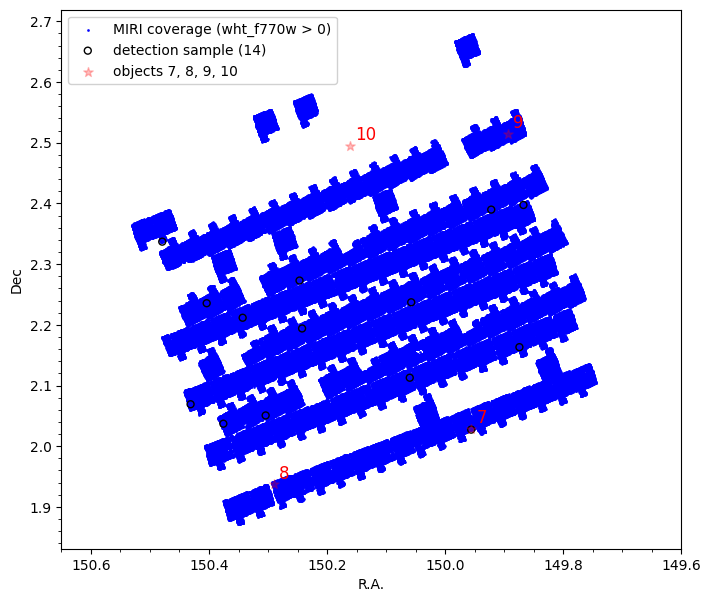

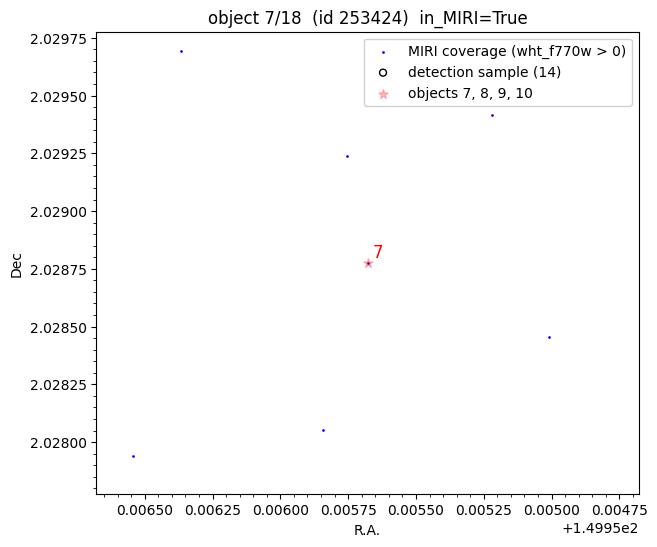

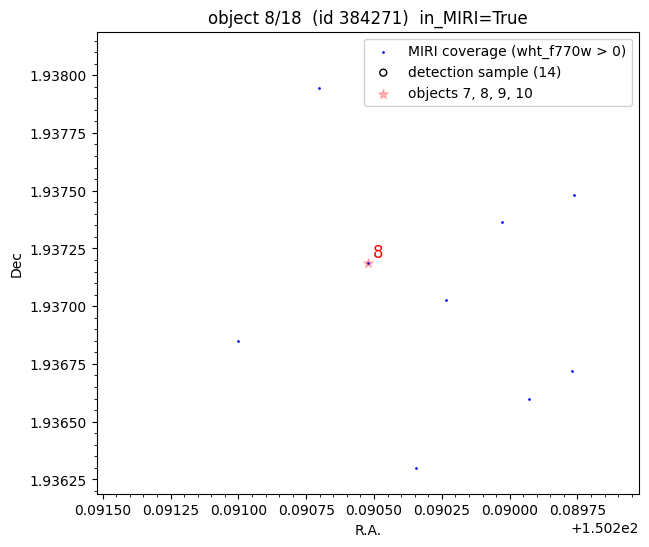

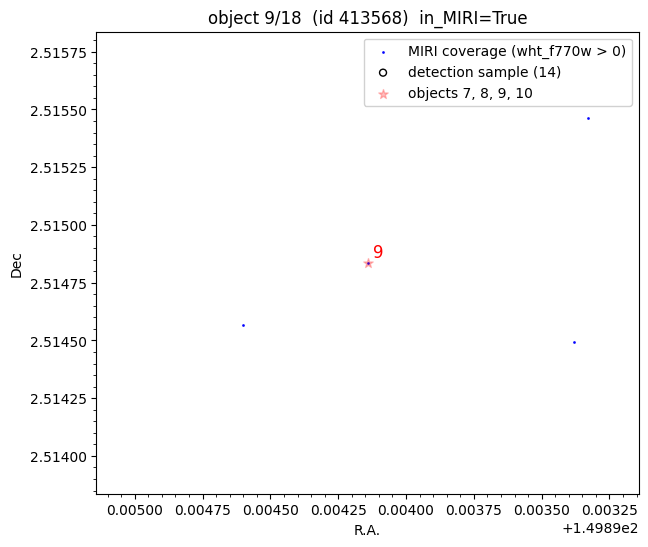

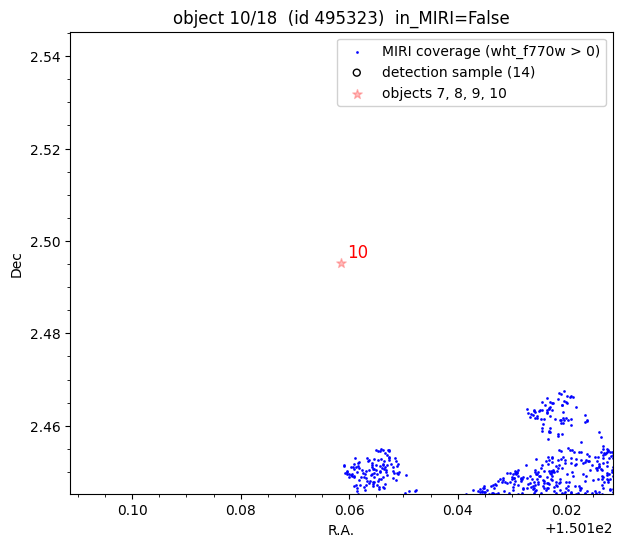

In [17]:
# Are objects 7/18, 8/18, 9/18, 10/18 inside MIRI (F770W) coverage?
# Reliable test = MIRI weight at the source: wht_f770w > 0. (flux_model_f770w can
# be a spurious forced value with zero exposure -- snr_f770w is NaN exactly where
# wht_f770w == 0, which is the catalog telling us "no MIRI data here".)

det  = cosmosWebHandler.get_cat_photom('condition_detection')   # READ-ONLY: never mutate this
allp = cosmosWebHandler.get_cat_photom('original')

# MIRI footprint = sources with positive F770W weight (real exposure)
wht_all  = np.asarray(allp['wht_f770w'], dtype=float)
miri_cov = np.isfinite(wht_all) & (wht_all > 0)
cov_ra, cov_dec = np.asarray(allp['ra'])[miri_cov], np.asarray(allp['dec'])[miri_cov]

picks = [7, 8, 9, 10]                  # 1-based labels in the 18-object sample
pick_ids = [253424, 384271, 413568, 495323]
pick_idx = [p - 1 for p in picks]      # -> 0-based rows
sub = det[pick_idx]                    # the highlighted objects

# detection sample WITHOUT the picks -- use a mask, do NOT remove rows from det
keep = np.ones(len(det), dtype=bool)
keep[pick_idx] = False
det_rest = det[keep]

print(f"{'obj':6}{'id':>9}{'RA':>11}{'Dec':>10}{'wht_f770w':>12}{'snr_f770w':>11}{'in_MIRI':>9}")
for n, row in zip(picks, sub):
    w = float(row['wht_f770w'])
    print(f"{f'{n}/18':6}{row['id']:>9}{row['ra']:>11.5f}{row['dec']:>10.5f}"
          f"{w:>12.4g}{float(row['snr_f770w']):>11.3g}{str(w > 0):>9}")


def _sky_panel(ax, center=None, zoom=None):
    ax.scatter(cov_ra, cov_dec, s=1, color='blue', alpha=0.9, rasterized=True,
               label='MIRI coverage (wht_f770w > 0)')
    ax.scatter(det_rest['ra'], det_rest['dec'], s=25, facecolor='none', edgecolor='k',
               label=f'detection sample ({len(det_rest)})')
    ax.scatter(sub['ra'], sub['dec'], s=50, marker='*', color='red', alpha = 0.25, zorder=5,
               label='objects 7, 8, 9, 10')
    for n, row in zip(picks, sub):
        ax.annotate(str(n), (row['ra'], row['dec']), color='red', fontsize=12,
                    xytext=(4, 4), textcoords='offset points', zorder=6)
    if center is not None:               # RA increases to the left -> (high, low)
        ax.set_xlim(center['ra'] + zoom, center['ra'] - zoom)
        ax.set_ylim(center['dec'] - zoom, center['dec'] + zoom)
    else:
        ax.set_xlim(150.65, 149.6)
    ax.set_xlabel('R.A.'); ax.set_ylabel('Dec')
    ax.legend(loc='best', framealpha=0.9); ax.minorticks_on()


# full-field view
fig, ax = plt.subplots(figsize=(8, 7))
_sky_panel(ax)
plt.show()

# zoomed views: (object label, row, half-width in deg)
med_zoom, high_zoom = 0.05, 0.001   # ~3 arcmin and ~18 arcsec on a side
zooms = [(7, sub[0], high_zoom), (8, sub[1], high_zoom),
         (9, sub[2], high_zoom), (10, sub[3], med_zoom)]
for n, row, z in zooms:
    fig, ax = plt.subplots(figsize=(7, 6))
    _sky_panel(ax, center=row, zoom=z)
    ax.set_title(f"object {n}/18  (id {row['id']})  in_MIRI={float(row['wht_f770w']) > 0}")
    plt.show()


In [22]:
# Why do 7/8 sit on MIRI coverage yet look empty in the inspection plot?
# They ARE in MIRI (wht_f770w > 0). Question: is the catalog F770W flux a real
# detection of the target, or contamination from a bright neighbour?
# Cross-check the three INDEPENDENT F770W measurements (model / SE++ auto / aperture)
# and the nearest neighbour. If they disagree -> the model S/N is not the target.
from astropy.coordinates import SkyCoord
import astropy.units as u

allp = cosmosWebHandler.get_cat_photom('original')
all_coord = SkyCoord(np.asarray(allp['ra']) * u.deg, np.asarray(allp['dec']) * u.deg)
mag444_all = np.asarray(allp['mag_model_f444w'], dtype=float)

det = cosmosWebHandler.get_cat_photom('condition_detection')
picks = [7, 8, 9, 10]
sub = det[[p - 1 for p in picks]]


def _sn(flux, err):
    err = float(err)
    return float(flux) / err if np.isfinite(err) and err > 0 else np.nan


for n, row in zip(picks, sub):
    c = SkyCoord(row['ra'] * u.deg, row['dec'] * u.deg)
    sep = c.separation(all_coord).arcsec
    nn = np.argsort(sep)[1]                     # [0] is the object itself
    sn_model = _sn(row['flux_model_f770w'], row['flux_err-cal_model_f770w'])
    sn_auto  = _sn(row['flux_auto_f770w'],  row['flux_err_auto_f770w'])
    sn_aper  = _sn(np.median(row['flux_aper_f770w']), np.median(row['flux_err_aper_f770w']))
    print(f"--- object {n}/18  id={row['id']}  in_MIRI={float(row['wht_f770w'])>0} "
          f"(wht={float(row['wht_f770w']):.3g}, catalog snr_f770w={float(row['snr_f770w']):.1f}) ---")
    print(f"    F770W S/N   model={sn_model:6.1f}   auto={sn_auto:6.1f}   aper={sn_aper:6.1f}")
    print(f"    F770W mag   model={float(row['mag_model_f770w']):6.2f}   auto={float(row['mag_auto_f770w']):6.2f}")
    print(f"    flags       star={row['flag_star']}  blend={row['flag_blend']}  group_id={row['group_id']}")
    print(f"    nearest nbr {sep[nn]:.2f}\"  (its F444W mag = {mag444_all[nn]:.2f})")


--- object 7/18  id=253424  in_MIRI=True (wht=1.8e+04, catalog snr_f770w=30.1) ---
    F770W S/N   model=  20.1   auto=  18.0   aper=   8.7
    F770W mag   model= 22.67   auto= 23.46
    flags       star=False  blend=False  group_id=17329
    nearest nbr 1.69"  (its F444W mag = 27.52)
--- object 8/18  id=384271  in_MIRI=True (wht=1.6e+04, catalog snr_f770w=23.6) ---
    F770W S/N   model=  10.9   auto=   9.9   aper=   5.6
    F770W mag   model= 25.48   auto= 25.42
    flags       star=False  blend=False  group_id=18078
    nearest nbr 1.19"  (its F444W mag = 25.89)
--- object 9/18  id=413568  in_MIRI=True (wht=3.37e+04, catalog snr_f770w=34.1) ---
    F770W S/N   model=  15.0   auto=  18.7   aper=   7.1
    F770W mag   model= 25.41   auto= 25.27
    flags       star=False  blend=False  group_id=4886
    nearest nbr 1.91"  (its F444W mag = 27.32)
--- object 10/18  id=495323  in_MIRI=False (wht=0, catalog snr_f770w=nan) ---
    F770W S/N   model=   6.4   auto=   nan   aper=   nan
    F77

In [9]:
cosmosWebHandler.get_cat_photom('condition_detection')[9]['id']

# from 'original' catalog, get the id of the 10th, 495323, object in the 'condition_detection' catalog, and print it out.
object_10 = cosmosWebHandler.get_cat_photom('condition_detection')[9]
print(object_10['id'])
object_10_original = cosmosWebHandler.get_cat_photom('original')[object_10['id']]
print(object_10_original['id'], object_10_original['flux_model_f770w'], object_10_original['flux_err-cal_model_f770w'], object_10_original['flux_model_f770w']/object_10_original['flux_err-cal_model_f770w'])

495323
495323 0.1291280579436395 0.02032452239257733 6.353313275927116


## remove bad selections

#### remove bad detections from flux_model

In [10]:
# for object 10/18 double check ['flux_model_f770w']>0 is true for this object
objects_to_remove = [2,6,7,8,10,11,14]

In [13]:
#manually remove the sketchy objects
sketchy_ids = []
for obj in objects_to_remove:
    sketchy_ids.append(cosmosWebHandler.get_cat_photom('condition_detection')[obj-1]['id'])  # obj is 1-based, sub is 0-based
condition_detection_reviewed = cosmosWebHandler.get_filter_cut(filtername='condition_detection_reviewed', filter_func=lambda photom, lephare, cigale, bd: ~np.isin(photom['id'], sketchy_ids), filter_to_take_from='condition_detection')


Filter cut: 11 out of 18 objects remain. Fraction: 61.11%


#### remove bad detections from flux_aper

In [220]:
condition_detection_reviewed = cosmosWebHandler.get_filter_cut(filtername='condition_detection_reviewed', filter_func=lambda photom, lephare, cigale, bd: photom['id'] != None, filter_to_take_from='condition_detection_aper')

Filter cut: 29 out of 29 objects remain. Fraction: 100.00%


# cross-ref

## cross-ref super-deblended

In [35]:
superDeblendedHandler = SuperDeblendedHandler(SUPER_DEBLENDED_CATALOG)
superDeblendedHandler.load_catalog()

Filename: /Volumes/Apple SDXC Reader Media/dusty-red/data/super-deblended/COSMOS_deblended_FIR_201821_photo_phys_2023June.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       5   ()      
  1  Joined        1 BinTableHDU    200   201821R x 83C   [J, D, D, E, E, I, D, D, E, D, D, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, E, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D]   
 HDU Info: None
Catalog loaded successfully.


In [66]:
print(f"num objects in super-deblended catalog: {len(superDeblendedHandler.cat_photom['original'])}")

num objects in super-deblended catalog: 201821


#### cross-ref via id

In [57]:
# print(superDeblendedHandler.cat_photom['original'].colnames)
#get the objects in the super-deblended catalog that are in the 'condition_detection_reviewed' catalog, and print out their fluxes in the super-deblended catalog.
for obj in cosmosWebHandler.get_cat_photom('condition_detection_reviewed'):
    # print(obj)
    obj_id = obj['id']
    print(f"Object ID: {obj_id} in condition_detection_reviewed")
    # print(superDeblendedHandler.cat_photom['original'])
    obj_idx_superDeblended = np.nan
    for i, row in enumerate(superDeblendedHandler.cat_photom['original']['ID']):
        if row == obj_id:
            obj_idx_superDeblended = i
            break
    if np.isnan(obj_idx_superDeblended):
        print(f"Object ID: {obj_id} not found in super-deblended catalog")
        continue
    print(f"\nOriginal: \n{cosmosWebHandler.get_cat_photom('original')[obj_id]}")
    print(f"Super Deblended: \n{superDeblendedHandler.cat_photom['original'][obj_idx_superDeblended]}")
    print(f"Object ID: {superDeblendedHandler.cat_photom['original'][obj_idx_superDeblended]['ID']} in super-deblended catalog")
    superDeblended_obj = superDeblendedHandler.cat_photom['original'][obj_idx_superDeblended]
    print(f"Object ID: {obj_id}, Super-Deblended photo_red : {superDeblended_obj['z_phot']}, spect_red: {superDeblended_obj['z_spec']} \n")

['ID', 'RA', 'Dec', 'z_phot', 'z_spec', 'goodArea', 'SNR_IR', 'z_FIR', 'ez_FIR', 'SFR_IR', 'eSFR_IR', 'f24', 'df24', 'f100', 'df100', 'f160', 'df160', 'f250', 'df250', 'f350', 'df350', 'f450', 'df450', 'f500', 'df500', 'f850_s2cosmos', 'df850_s2cosmos', 'f850_studies', 'df850_studies', 'f1100', 'df1100', 'f1200', 'df1200', 'f10cm', 'df10cm', 'f20cm', 'df20cm', 'f23cm', 'df23cm', 'f870_alma', 'df870_alma', 'f1000_alma', 'df1000_alma', 'f1250_alma', 'df1250_alma', 'f2100_alma', 'df2100_alma', 'f3100_alma', 'df3100_alma', 'LIR_AGN', 'eLIR_AGN', 'LIR_tot', 'eLIR_tot', 'Ubest', 'chi2_min', 'S_chi2_min', 'R_chi2_min', 'xf70', 'xe70', 'xf100', 'xe100', 'xf160', 'xe160', 'xf250', 'xe250', 'xf350', 'xe350', 'xf500', 'xe500', 'xf850', 'xe850', 'xf1100', 'xe1100', 'xf1200', 'xe1200', 'xf2000', 'xe2000', 'xf3000', 'xe3000', 'xf10cm', 'xe10cm', 'xf20cm', 'xe20cm']
Object ID: 9404 in condition_detection_reviewed
Object ID: 9404 not found in super-deblended catalog
Object ID: 171453 in condition_dete

#### cross-ref via RA,DEC

In [ ]:
#instead match the objects by ra, dec with tolerance of 0.5 arcsec, and print out their fluxes in the super-deblended catalog.
from astropy.coordinates import SkyCoord
import astropy.units as u
tolerance = 1 * u.arcsec
superDeblended_ids_matched = []
matched_super_deblended : dict[int, Table] = {} # key is the id of the object in the condition_detection_reviewed catalog, value is the row in the super-deblended catalog that matches it.
closest_match_super_deblended : dict[int, Table] = {} # key is the id of the object in the condition_detection_reviewed catalog, value is the row in the super-deblended catalog that is the closest match to it, even if it is outside the tolerance.
for obj in cosmosWebHandler.get_cat_photom('condition_detection_reviewed'):
    obj_coord = SkyCoord(obj['ra'] * u.deg, obj['dec'] * u.deg)
    found_match = False
    closest_match = None
    closest_sep = np.inf * u.arcsec
    for row in superDeblendedHandler.cat_photom['original']:
        # print(row)
        row_coord = SkyCoord(row['RA'] * u.deg, row['Dec'] * u.deg)
        sep = obj_coord.separation(row_coord)
        if sep < tolerance:
            print(f"\nObject ID: {obj['id']} in condition_detection_reviewed matches with Super-Deblended ID: {row['ID']} at separation {sep.arcsec:.2f} arcsec")
            original_cols_to_print = ['id', 'ra', 'dec', 'flux_aper_f115w', 'flux_err_aper_f115w', 'flux_aper_f150w', 'flux_err_aper_f150w', 'flux_aper_f444w', 'flux_err_aper_f444w', 'flux_aper_f770w', 'flux_err_aper_f770w']
            original_info = {col: obj[col] for col in original_cols_to_print}
            # print(f"Original: \n{cosmosWebHandler.get_cat_photom('original')[obj['id']]}")
            print(f"Original: \n{original_info}")
            print(f"Super Deblended: \n{row}")
            print(f"Object ID: {row['ID']} in super-deblended catalog")
            print(f"Object ID: {obj['id']}, Super-Deblended photo_red : {row['z_phot']}, spect_red: {row['z_spec']} \n\n")
            found_match = True
            superDeblended_ids_matched.append(row['ID'])
            matched_super_deblended[obj['id']] = row
            break
        if sep < closest_sep:
            closest_sep = sep
            closest_match = row
    if not found_match:
        print(f"Object ID: {obj['id']} not found in super-deblended catalog within {tolerance}")
        closest_match_super_deblended[obj['id']] = closest_match
        print(f"Closest match is Super-Deblended ID: {closest_match['ID']} at separation {closest_sep.arcsec:.2f} arcsec\n\n")

# #filter the super-deblended catalog to only include the matched objects, and print out the number of matched objects and their IDs.
# matched_super_deblended = superDeblendedHandler.get_filter_cut(filtername='matched_super_deblended', filter_func=lambda photom: np.isin(photom['ID'], superDeblended_ids_matched), filter_to_take_from='original')
        

Object ID: 17338 not found in super-deblended catalog within 1.0 arcsec
Closest match is Super-Deblended ID: 495276 at separation 11.48 arcsec


Object ID: 26910 not found in super-deblended catalog within 1.0 arcsec
Closest match is Super-Deblended ID: 194027 at separation 5.29 arcsec


Object ID: 56404 not found in super-deblended catalog within 1.0 arcsec
Closest match is Super-Deblended ID: 37801 at separation 2.40 arcsec


Object ID: 79810 not found in super-deblended catalog within 1.0 arcsec
Closest match is Super-Deblended ID: 30495008 at separation 8.19 arcsec


Object ID: 92586 not found in super-deblended catalog within 1.0 arcsec
Closest match is Super-Deblended ID: 89829 at separation 3.57 arcsec


Object ID: 96066 not found in super-deblended catalog within 1.0 arcsec
Closest match is Super-Deblended ID: 156908 at separation 7.77 arcsec


Object ID: 136802 not found in super-deblended catalog within 1.0 arcsec
Closest match is Super-Deblended ID: 412062 at separation 10.2

In [ ]:
print(f"Number of matched objects in super-deblended catalog: {len(superDeblended_ids_matched)}, matched catalog length: {len(superDeblendedHandler.get_cat_photom('matched_super_deblended'))}")
print(superDeblendedHandler.get_cat_photom('matched_super_deblended'))

Number of matched objects in super-deblended catalog: 2, matched catalog length: 2
  ID           RA                Dec         ...  xe10cm   xf20cm  xe20cm 
------ ------------------ ------------------ ... -------- ------- --------
 39233  150.3431296459875 2.2115380275028476 ... 0.001343 0.01348 0.002335
836111 150.37594432462345 2.0372350066664455 ...  0.00696 0.08402  0.01212


## cross-ref MIGHTEE

In [61]:
mighteeHandler = MighteeHandler(MIGHTEE_CATALOG)
mighteeHandler.load_catalog()
print(mighteeHandler.hdr)

Filename: /Volumes/Apple SDXC Reader Media/dusty-red/data/mightee_continuum/MIGHTEE_Continuum_DR1_COSMOS_5p2arcsec_I_v1.1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      32   (7486, 7486)   float64   
 HDU Info: None
Catalog loaded successfully.
SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                  -64 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                 7486                                                  NAXIS2  =                 7486                                                  CTYPE1  = 'RA---TAN'                                                            CTYPE2  = 'DEC--TAN'                                                            CTYPE3  = 'FREQ    '                                                            CTYPE4  = 'STOKES  '                                      

### get the intensity at all points ... can remove non detections later

In [144]:
#given that MIGHTEE catalog is just the intensity image, where each col and row corresponds to a pixel in the image, we can use the WCS information in the header to convert the ra, dec of our objects to pixel coordinates, and then extract the intensity value at those pixel coordinates from the MIGHTEE catalog.
from astropy.wcs import WCS
from astropy.io import fits
# The MIGHTEE header keeps leftover FREQ/STOKES axes (4-D WCS) over a 2-D image,
# so use .celestial to get a clean 2-D (RA, Dec) WCS that takes a single SkyCoord.
mightee_header = mighteeHandler.hdr
wcs = WCS(mightee_header).celestial
print(f"distance between pixels in arcsec: {wcs.proj_plane_pixel_scales()[0].to(u.arcsec)}")

# Ensure we index a 2-D ndarray (Astropy Table does not support [y, x] tuple access)
mightee_image = mighteeHandler.cat_photom['original']
if hasattr(mightee_image, "as_array"):  # astropy.table.Table
    mightee_image = np.asarray(mightee_image.as_array().tolist(), dtype=float)
else:
    mightee_image = np.asarray(mightee_image, dtype=float)
mightee_image = np.squeeze(mightee_image)

# Loop through the objects in the condition_detection_reviewed catalog and extract MIGHTEE intensity values
# take a 0.5 arcsec radius around the position of each object and average the MIGHTEE intensity values within that radius to get a more robust measurement, since the MIGHTEE pixel scale is 1.1 arcsec/pixel, so 0.5 arcsec corresponds to about 0.45 pixels, we can use a 3x3 pixel box centered on the object's position to capture the nearby pixels.
from astropy.coordinates import SkyCoord
import astropy.units as u

intensity_dic = {}  # key is the id of the object in the condition_detection_reviewed catalog, value is a tuple of the center pixel coordinates of the object in the MIGHTEE image, central intensity value at the object's position in the MIGHTEE image, the average intensity in the 3x3 pixel box around the object's position in the MIGHTEE image, and peak intensity value in the 3x3 pixel box around the object's position in the MIGHTEE image.
for obj in cosmosWebHandler.get_cat_photom('condition_detection_reviewed'):
    ra, dec = obj['ra'], obj['dec']
    x_pixel, y_pixel = wcs.world_to_pixel(SkyCoord(ra * u.deg, dec * u.deg))
    x_pixel, y_pixel = int(round(float(x_pixel))), int(round(float(y_pixel)))
    if (0 <= x_pixel < mightee_image.shape[1]) and (0 <= y_pixel < mightee_image.shape[0]):
        # Extract a 3x3 pixel box around the object's position
        x_min = max(0, x_pixel - 1)
        x_max = min(mightee_image.shape[1], x_pixel + 2)
        y_min = max(0, y_pixel - 1)
        y_max = min(mightee_image.shape[0], y_pixel + 2)
        intensity_box = mightee_image[y_min:y_max, x_min:x_max]
        intensity_avg = np.nanmean(intensity_box)  # Average intensity in the box
        intensity_peak = np.nanmax(intensity_box)  # Peak intensity in the box
        intensity_dic[obj['id']] = (x_pixel, y_pixel, mightee_image[y_pixel, x_pixel], intensity_avg, intensity_peak)
        print(f"Object ID: {obj['id']}, RA: {ra}, Dec: {dec}, MIGHTEE Intensity point: {mightee_image[y_pixel, x_pixel]}, MIGHTEE Intensity avg: {intensity_avg}, MIGHTEE Intensity peak: {intensity_peak}")
    else:
        print(f"Object ID: {obj['id']} is out of MIGHTEE image bounds.")
        
        
#create mightee table with columns, 'COSMOS-Web ID', 'RA', 'Dec', 'MIGHTEE Intensity'
mightee_table = Table(names=['COSMOS-Web ID', 'RA', 'Dec', 'MIGHTEE Intensity point', 'MIGHTEE Intensity avg', 'MIGHTEE Intensity peak'], dtype=[int, float, float, float, float, float])
for obj in cosmosWebHandler.get_cat_photom('condition_detection_reviewed'):
    obj_id = obj['id']
    ra, dec = obj['ra'], obj['dec']
    if obj_id in intensity_dic:
        intensity_point = intensity_dic[obj_id][2]
        intensity_avg = intensity_dic[obj_id][3]
        intensity_peak = intensity_dic[obj_id][4]
        mightee_table.add_row((obj_id, ra, dec, intensity_point, intensity_avg, intensity_peak))
    else:
        mightee_table.add_row((obj_id, ra, dec, np.nan, np.nan, np.nan))  # Add NaN if intensity is not available

distance between pixels in arcsec: 1.1000016000000001 arcsec
Object ID: 9404, RA: 149.87433942683057, Dec: 2.163194204216337, MIGHTEE Intensity point: -2.5652053591354025e-06, MIGHTEE Intensity avg: -1.6794659337962325e-06, MIGHTEE Intensity peak: -3.625985723422645e-07
Object ID: 171453, RA: 150.3757311408659, Dec: 2.0370616649182076, MIGHTEE Intensity point: 1.072942794793936e-05, MIGHTEE Intensity avg: 9.181582265196218e-06, MIGHTEE Intensity peak: 1.3290357225670748e-05
Object ID: 177683, RA: 150.43122812754441, Dec: 2.0691383401847614, MIGHTEE Intensity point: 1.0692301314001861e-05, MIGHTEE Intensity avg: 9.246916520925091e-06, MIGHTEE Intensity peak: 1.252059371751966e-05
Object ID: 184688, RA: 150.30408375520628, Dec: 2.050699963766801, MIGHTEE Intensity point: -6.711737281093981e-07, MIGHTEE Intensity avg: -2.3701604704738535e-07, MIGHTEE Intensity peak: 3.4991931921216748e-06
Object ID: 413568, RA: 149.89414183942313, Dec: 2.5148364768547156, MIGHTEE Intensity point: -2.27074

#### aside, plot mini plots for mightee points around sources

In [202]:
#create plot with slider to cycle through the objects in the condition_detection_reviewed catalog, showing their positions on the MIGHTEE image and their intensity values.
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import io
import ipywidgets as widgets
from IPython.display import display
_slider_mightee = widgets.IntSlider(min=0, max=len(cosmosWebHandler.get_cat_photom('condition_detection_reviewed')) - 1, step=1, value=0, description='object')
_prev_mightee = widgets.Button(description='◀ Prev')
_next_mightee = widgets.Button(description='Next ▶')
_out_mightee = widgets.Output()

zoom_size_arcsec = 5.75 + 10 # in arcsec
zoom_size_pixels = int(zoom_size_arcsec / wcs.proj_plane_pixel_scales()[0].to(u.arcsec).value)  # convert zoom size to pixels
print(f"Zoom size in pixels: {zoom_size_pixels} pixels (for {zoom_size_arcsec} arcsec at MIGHTEE pixel scale)")

def _show_mightee_zoomed_with_cosmos_web_interface(i):
    pdf_url_sourceid = lambda sid: f"https://cosmos2025.iap.fr/fitsmap/data/inspec_plots/cosmos_web_sed_{sid}.pdf"
    with _out_mightee:
        _out_mightee.clear_output(wait=True)
        obj = cosmosWebHandler.get_cat_photom('condition_detection_reviewed')[i]
        obj_id = obj['id']
        ra, dec = obj['ra'], obj['dec']
        intensity_info = intensity_dic.get(obj_id, (np.nan, np.nan, np.nan, np.nan, np.nan))
        x_pixel, y_pixel, intensity_point, intensity_avg, intensity_peak = intensity_info
        
        fig, ax = plt.subplots(figsize=(10, 20), nrows=1, ncols=2, width_ratios=[2.5, 1], gridspec_kw={'wspace': 0.05})
        # zoom_size = 70  # pixels
        zoom_size = zoom_size_pixels
        x_min = max(0, x_pixel - zoom_size)
        x_max = min(mightee_image.shape[1], x_pixel + zoom_size)
        y_min = max(0, y_pixel - zoom_size)
        y_max = min(mightee_image.shape[0], y_pixel + zoom_size)
        ax[1].imshow(mightee_image[y_min:y_max, x_min:x_max], origin='lower', cmap='gray', vmin=np.nanpercentile(mightee_image[y_min:y_max, x_min:x_max], 5), vmax=np.nanpercentile(mightee_image[y_min:y_max, x_min:x_max], 95))
        if not np.isnan(x_pixel) and not np.isnan(y_pixel):
            sizeOfMarkerArcSec = 5.2  # in arcsec
            sizeOfMarkerPixels = (sizeOfMarkerArcSec / wcs.proj_plane_pixel_scales()[0].to(u.arcsec).value) ** 2  # convert size to pixels^2 for scatter plot
            pixscale_arcsec = wcs.proj_plane_pixel_scales()[0].to(u.arcsec).value
            radius_pix = sizeOfMarkerArcSec / pixscale_arcsec  # radius in image pixels

            p0 = ax[1].transData.transform((0, 0))
            p1 = ax[1].transData.transform((radius_pix, 0))
            radius_pts = (p1[0] - p0[0]) * 72.0 / fig.dpi

            sizeOfMarker = np.pi * (radius_pts ** 2)  # scatter expects area in points^2
            ax[1].scatter(x_pixel - x_min, y_pixel - y_min, s=sizeOfMarker, edgecolor='red', facecolor='none', label=f'ID: {obj_id} @ 5.2"')
            # ax[1].legend(loc='upper right', )
            
            #highlight box to match the size of the cosmic web interface inspection plot, which is 5.75 arcsec on a side, so 5.75/2 = 2.875 arcsec from the center to the edge
            box_size_arcsec = 5.75  # in arcsec
            box_size_pixels = box_size_arcsec / wcs.proj_plane_pixel_scales()[0].to(u.arcsec).value  # convert box size to pixels
            rect = plt.Rectangle((x_pixel - x_min - box_size_pixels / 2, y_pixel - y_min - box_size_pixels / 2), box_size_pixels, box_size_pixels, edgecolor='dodgerblue', facecolor='none', linestyle='--', label='Inspection equivalent')
            ax[1].add_patch(rect)
            # ax[1].legend(loc='upper right', fontsize=8)
            
        ax[1].set_title(f"Zoomed view of Object ID: {obj_id}\nMIGHTEE Intensity point: {intensity_point:.3g}, avg: {intensity_avg:.3g}, peak: {intensity_peak:.3g}")
        
        #include scale bar of 2 arcsec in the zoomed image
        import matplotlib.patheffects as pe
        scale_bar_length_arcsec = 2  # arcsec
        scale_bar_length_pixels = scale_bar_length_arcsec / wcs.proj_plane_pixel_scales()[0].to(u.arcsec).value
        crop_h, crop_w = (y_max - y_min), (x_max - x_min)
        margin = 0.05 * crop_h
        x0 = margin
        y0 = margin  # anchor near the bottom-left of the actual crop, not zoom_size
        outline = [pe.withStroke(linewidth=4, foreground='black')]
        ax[1].plot([x0, x0 + scale_bar_length_pixels], [y0, y0], color='white', linewidth=2.5,
                   solid_capstyle='butt', path_effects=outline)
        ax[1].text(x0, y0 + 0.02 * crop_h, f'{scale_bar_length_arcsec} arcsec', color='white',
                   fontsize=8, va='bottom', path_effects=outline)
        ax[1].axis('off')
        
        #put a 2 arcsec scale bar in the zoomed box 
        # scale_bar_for_box_length_arcsec = 2  # arcsec
        # scale_bar_for_box_length_pixels = scale_bar_for_box_length_arcsec / wcs.proj_plane_pixel_scales()[0].to(u.arcsec).value
        # box_margin = 0.05 * box_size_pixels
        # x0_box = zoom_size - box_margin - scale_bar_for_box_length_pixels  # anchor near the bottom-right of the box
        # y0_box = zoom_size - box_margin  # anchor near the bottom-right of the box
        # ax[1].plot([x0_box, x0_box + scale_bar_for_box_length_pixels], [y0_box, y0_box], color='yellow', linewidth=2.5,
        #            solid_capstyle='butt', path_effects=outline)
        # ax[1].text(x0_box, y0_box - 0.02 * box_size_pixels, f'{scale_bar_for_box_length_arcsec} arcsec', color='yellow',
        #            fontsize=8, va='top', ha='right', path_effects=outline)
        ax[1].legend(loc='upper right', fontsize=8, markerscale=0.05)
        
        # Display the COSMOS-Web inspection plot for the object
        if fitz is None:
            print("Install PyMuPDF to render the inspection plots:  pip install pymupdf")
            print("Direct link:", pdf_url_sourceid(obj_id))
            return
        try:
            for png in _render_pdf(obj_id):
                ax[0].imshow(mpimg.imread(io.BytesIO(png)))
                ax[0].axis('off')
                ax[0].set_title("COSMOS-Web inspection plot")

        except Exception as e:
            print(f"Could not load plot for id={obj_id}: {e}")
            print("Direct link:", pdf_url_sourceid(obj_id))
        
        plt.show()
        
_slider_mightee.observe(lambda change: _show_mightee_zoomed_with_cosmos_web_interface(change['new']), names='value')
_prev_mightee.on_click(lambda _: setattr(_slider_mightee, 'value', max(0, _slider_mightee.value - 1)))
_next_mightee.on_click(lambda _: setattr(_slider_mightee, 'value', min(len(cosmosWebHandler.get_cat_photom('condition_detection_reviewed')) - 1, _slider_mightee.value + 1)))
display(widgets.HBox([_prev_mightee, _slider_mightee, _next_mightee]), _out_mightee)
_show_mightee_zoomed_with_cosmos_web_interface(_slider_mightee.value)   # render the first object immediately




Zoom size in pixels: 14 pixels (for 15.75 arcsec at MIGHTEE pixel scale)


Output()

For flux-aper - good detections
- 


For flux-model - good detections
- object 7/11
- object 2/11
- object 3/11

## cross-ref alma

### ALMA prior

In [75]:
almaPriorHandler = AlmaHandler(ALMA_PRELIM_PRIOR_CATALOG)
almaPriorHandler.load_catalog()

Filename: /Volumes/Apple SDXC Reader Media/dusty-red/data/alma_prelim_catalog/Catalogs/champs_prior_catalog.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU     59   2019R x 19C   [K, D, D, D, D, D, D, D, D, D, D, L, J, L, K, L, K, L, J]   
 HDU Info: None
Catalog loaded successfully.


### ALMA Blind

In [76]:
almaBlindHandler = AlmaHandler(ALMA_PRELIM_BLIND_CATALOG)
almaBlindHandler.load_catalog()

Filename: /Volumes/Apple SDXC Reader Media/dusty-red/data/alma_prelim_catalog/Catalogs/champs_blind_catalog.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU     64   1777R x 22C   [K, D, D, E, E, E, D, D, L, K, L, J, L, K, L, K, L, J, D, D, D, D]   
 HDU Info: None
Catalog loaded successfully.


#### cross ref with id

In [80]:
#try simple check of id matching
for obj in cosmosWebHandler.get_cat_photom('condition_detection_reviewed'):
    obj_id = obj['id']
    print(f"Object ID: {obj_id} in condition_detection_reviewed")
    # Check in ALMA prior catalog
    prior_match = None
    for row in almaPriorHandler.cat_photom['original']:
        # print(row)
        if row['cosmos_id'] == obj_id:
            prior_match = row
            break
    if prior_match is not None:
        print(f"Found match in ALMA prior catalog for Object ID: {obj_id}")
        print(prior_match)
    else:
        print(f"No match found in ALMA prior catalog for Object ID: {obj_id}")
    
    # Check in ALMA blind catalog
    blind_match = None
    for row in almaBlindHandler.cat_photom['original']:
        if row['id'] == obj_id:
            blind_match = row
            break
    if blind_match is not None:
        print(f"Found match in ALMA blind catalog for Object ID: {obj_id}")
        print(blind_match)
    else:
        print(f"No match found in ALMA blind catalog for Object ID: {obj_id}")

Object ID: 9404 in condition_detection_reviewed
No match found in ALMA prior catalog for Object ID: 9404
No match found in ALMA blind catalog for Object ID: 9404
Object ID: 171453 in condition_detection_reviewed
Found match in ALMA prior catalog for Object ID: 171453
cosmos_id         ra               dec             peak_flux              rms                snr             total_flux        total_flux_err        f770w_flux          f770w_flux_err        f770w_snr      in_a3cosmos a3cosmos_id in_vla3ghz vla3ghz_id in_exmora exmora_id in_meerkat meerkat_id
--------- ----------------- ------------------ ------------------ ------------------- ------------------ ------------------ ------------------- -------------------- --------------------- ------------------ ----------- ----------- ---------- ---------- --------- --------- ---------- ----------
   171453 150.3757311408659 2.0370616649182076 2.8946774546056986 0.09590405534254387 30.183055877685547 2.8105885203015575 0.26087941572958045 

#### cross ref with RA,DEC

In [205]:
#try matching by ra, dec with tolerance of 1 arcsec
from astropy.coordinates import SkyCoord
import astropy.units as u
tolerance = 1 * u.arcsec
blind_matches_ids = []
prior_matches_ids = []
matched_prior : dict[int, Table] = {} # key is the id of the object in the condition_detection_reviewed catalog, value is the row in the ALMA prior catalog that matches it.
matched_blind : dict[int, Table] = {} # key is the id of the object in the condition_detection_reviewed catalog, value is the row in the ALMA blind catalog that matches it.

closest_match_prior : dict[int, Table] = {} # key is the id of the object in the condition_detection_reviewed catalog, value is the row in the ALMA prior catalog that is the closest match to it, even if it is outside the tolerance.
closest_match_blind : dict[int, Table] = {} # key is the id of the object in the condition_detection_reviewed catalog, value is the row in the ALMA blind catalog that is the closest match to it, even if it is outside the tolerance.
for obj in cosmosWebHandler.get_cat_photom('condition_detection_reviewed'):
    obj_coord = SkyCoord(obj['ra'] * u.deg, obj['dec'] * u.deg)
    print(f"Object ID: {obj['id']} in condition_detection_reviewed at RA={obj['ra']:.5f}, Dec={obj['dec']:.5f}")
    
    # Check in ALMA prior catalog
    prior_match = None
    closest_prior = float('inf')
    for row in almaPriorHandler.cat_photom['original']:
        row_coord = SkyCoord(row['ra'] * u.deg, row['dec'] * u.deg)
        separation = obj_coord.separation(row_coord)
        if separation < tolerance:
            prior_match = row
            break
        if separation < closest_prior:
            closest_prior = separation
            closest_match_prior[obj['id']] = row
    if prior_match is not None:
        print(f"Found match in ALMA prior catalog for Object ID: {obj['id']} at separation {obj_coord.separation(row_coord).arcsec:.2f} arcsec")
        print(prior_match)
        prior_matches_ids.append(prior_match['cosmos_id'])
        matched_prior[obj['id']] = prior_match
    else:
        print(f"No match found in ALMA prior catalog for Object ID: {obj['id']} within {tolerance}")
    
    # Check in ALMA blind catalog
    blind_match = None
    closest_blind = float('inf')
    for row in almaBlindHandler.cat_photom['original']:
        row_coord = SkyCoord(row['ra'] * u.deg, row['dec'] * u.deg)
        separation = obj_coord.separation(row_coord)
        if separation < tolerance:
            blind_match = row
            break
        if separation < closest_blind:
            closest_blind = separation
            closest_match_blind[obj['id']] = row
    if blind_match is not None:
        print(f"Found match in ALMA blind catalog for Object ID: {obj['id']} at separation {obj_coord.separation(row_coord).arcsec:.2f} arcsec")
        print(blind_match)
        blind_matches_ids.append(blind_match['id'])
        matched_blind[obj['id']] = blind_match
    else:
        print(f"No match found in ALMA blind catalog for Object ID: {obj['id']} within {tolerance}")
    
    if obj['id'] in matched_prior:
        print(f"ALMA Prior match for Object ID {obj['id']}: {matched_prior[obj['id']]}")
    else:
        if obj['id'] in closest_match_prior:
            print(f"Closest ALMA Prior match for Object ID {obj['id']} is at separation {closest_prior.arcsec:.2f} arcsec: {closest_match_prior[obj['id']]}")
    if obj['id'] in matched_blind:
        print(f"ALMA Blind match for Object ID {obj['id']}: {matched_blind[obj['id']]}\n\n")
    else:
        if obj['id'] in closest_match_blind:
            print(f"Closest ALMA Blind match for Object ID {obj['id']} is at separation {closest_blind.arcsec:.2f} arcsec: {closest_match_blind[obj['id']]}\n\n")
        
        
# #filter the ALMA prior and blind catalogs to only include the matches, and print out the filtered catalogs.
# filtered_prior = almaPriorHandler.get_filter_cut(filtername='alma_prior_matches', filter_func=lambda photom: np.isin(photom['cosmos_id'], prior_matches_ids), filter_to_take_from='original')
# filtered_blind = almaBlindHandler.get_filter_cut(filtername='alma_blind_matches', filter_func=lambda photom: np.isin(photom['id'], blind_matches_ids), filter_to_take_from='original')

Object ID: 9404 in condition_detection_reviewed at RA=149.87434, Dec=2.16319
No match found in ALMA prior catalog for Object ID: 9404 within 1.0 arcsec
No match found in ALMA blind catalog for Object ID: 9404 within 1.0 arcsec
Closest ALMA Prior match for Object ID 9404 is at separation 7.86 arcsec: cosmos_id         ra                dec             peak_flux              rms                snr            total_flux        total_flux_err        f770w_flux         f770w_flux_err         f770w_snr      in_a3cosmos a3cosmos_id in_vla3ghz vla3ghz_id in_exmora exmora_id in_meerkat meerkat_id
--------- ------------------ ------------------ ------------------ ------------------- ----------------- ------------------ ------------------- ------------------- ---------------------- ------------------ ----------- ----------- ---------- ---------- --------- --------- ---------- ----------
     9231 149.87244982703425 2.1620975045898057 0.5024510901421309 0.08535326924175024 5.886723518371582 0.4327

In [99]:
print(f"Number of matched objects in alma prior catalog: {len(prior_matches_ids)}")
print(f"Number of matched objects in alma blind catalog: {len(blind_matches_ids)}")

Number of matched objects in alma prior catalog: 2
Number of matched objects in alma blind catalog: 2


#### visually inspect CHAMPS with pbcorr40

In [ ]:
#read CHAMPS image from fits file and extract the pixel values at the positions of the objects in the condition_detection_reviewed catalog, using the WCS information in the CHAMPS image header to convert the ra, dec of the objects to pixel coordinates in the CHAMPS image.
from astropy.io import fits
from astropy.wcs import WCS
champs_fits = fits.open(ALMA_IMAGE_MAP40)
champs_image = champs_fits[0].data
champs_header = champs_fits[0].header
champs_wcs = WCS(champs_header)
champs_intensity_dic = {}  # key is the id of the object in the condition_detection_reviewed catalog, value is a tuple of the center pixel coordinates of the object in the CHAMPS image, and the intensity value at that position.
for obj in cosmosWebHandler.get_cat_photom('condition_detection_reviewed'):
    ra, dec = obj['ra'], obj['dec']
    x_pixel, y_pixel = champs_wcs.world_to_pixel(SkyCoord(ra * u.deg, dec * u.deg))
    x_pixel, y_pixel = int(round(float(x_pixel))), int(round(float(y_pixel)))
    if (0 <= x_pixel < champs_image.shape[1]) and (0 <= y_pixel < champs_image.shape[0]):
        intensity_value = champs_image[y_pixel, x_pixel]
        champs_intensity_dic[obj['id']] = (x_pixel, y_pixel, intensity_value)
        print(f"Object ID: {obj['id']}, RA: {ra}, Dec: {dec}, CHAMPS Intensity: {intensity_value}")
    else:
        print(f"Object ID: {obj['id']} is out of CHAMPS image bounds.")
        
        

In [ ]:
#create plot with slider to cycle through the objects in the condition_detection_reviewed catalog, showing their positions on the CHAMPS image.
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import io
import ipywidgets as widgets
from IPython.display import display
_slider_champs = widgets.IntSlider(min=0, max=len(cosmosWebHandler.get_cat_photom('condition_detection_reviewed')) - 1, step=1, value=0, description='object')
_prev_champs = widgets.Button(description='◀ Prev')
_next_champs = widgets.Button(description='Next ▶')
_out_champs = widgets.Output()

def _show_champs_zoomed_with_cosmos_web_interface(i):
    pdf_url_sourceid = lambda sid: f"https://cosmos2025.iap.fr/fitsmap/data/inspec_plots/cosmos_web_sed_{sid}.pdf"
    with _out_champs:
        _out_champs.clear_output(wait=True)
        obj = cosmosWebHandler.get_cat_photom('condition_detection_reviewed')[i]
        obj_id = obj['id']
        ra, dec = obj['ra'], obj['dec']
        
        fig, ax = plt.subplots(figsize=(10, 20), nrows=1, ncols=2, width_ratios=[2.5, 1], gridspec_kw={'wspace': 0.05})
        
        # Display the CHAMPS image for the object
        try:
            champs_image_data = mpimg.imread(f"https://champsportal.com/thumbnail?ra={ra}&dec={dec}&size=200&format=png")
            ax[0].imshow(champs_image_data, origin='lower')
            ax[0].set_title(f"CHAMPS image for Object ID: {obj_id}")
            ax[0].axis('off')
        except Exception as e:
            print(f"Could not load CHAMPS image for id={obj_id}: {e}")
        
        # Display the COSMOS-Web inspection plot for the object
        if fitz is None:
            print("Install PyMuPDF to render the inspection plots:  pip install pymupdf")
            print("Direct link:", pdf_url_sourceid(obj_id))
            return
        try:
            for png in _render_pdf(obj_id):
                ax[1].imshow(mpimg.imread(io.BytesIO(png)))
                ax[1].axis('off')
                ax[1].set_title("COSMOS-Web inspection plot")
        except Exception as e:
            print(f"Could not load plot for id={obj_id}: {e}")
            print("Direct link:", pdf_url_sourceid(obj_id))
        
        plt.show()

## create super table

In [145]:
#create super table that combines info for all the detected sources from JWST (~11)
#columns: id (0-10), has_cross_match_in_super_deblended (True/False), has_cross_match_in_mightee (True/False), has_cross_match_in_alma_prior (True/False), has_cross_match_in_alma_blind (True/False), jwst_columns..., super_deblended_columns..., mightee_intensity, ALMA_prior_columns..., ALMA_blind_columns..., and also the separation between the JWST source and the matched source in each catalog if there is a match.

#use cosmosWebHandler.get_cat_photom('condition_detection_reviewed'), superDeblendedHandler.get_cat_photom('matched_super_deblended'), mightee_table, almaHandler.get_cat_photom('alma_prior_matches'), almaBlindHandler.get_cat_photom('alma_blind_matches') to get the relevant catalogs, and then merge them based on the IDs or ra, dec matching with tolerance of 1 arcsec.
from astropy.table import Table, vstack
combined_rows = []
for i, obj in enumerate(cosmosWebHandler.get_cat_photom('condition_detection_reviewed')):
    row = {}
    row['id'] = i
    #put the COSMOS-Web info in the row
    # row['COSMOS-Web_id'] = obj['id']
    # row['COSMOS-Web_ra'] = obj['ra']
    # row['COSMOS-Web_dec'] = obj['dec']
    for col in cosmosWebHandler.get_cat_photom('condition_detection_reviewed').colnames:
        row[f'COSMOS-Web_{col}'] = obj[col]
    
    # Check for match in super-deblended with matched_super_deblended dict
    super_deblended_match = matched_super_deblended.get(obj['id'], None)
    row['has_cross_match_in_super_deblended'] = int(super_deblended_match is not None)
    if super_deblended_match is not None:
        for col in superDeblendedHandler.cat_photom['matched_super_deblended'].colnames:
            row[f'super_deblended_{col}'] = super_deblended_match[col]
    else:
        for col in superDeblendedHandler.cat_photom['matched_super_deblended'].colnames:
            row[f'super_deblended_{col}'] = np.nan
    #put the super-deblended info in the row if there is a match, otherwise put NaN
    if super_deblended_match is not None:
        for col in superDeblendedHandler.cat_photom['matched_super_deblended'].colnames:
            row[f'super_deblended_{col}'] = super_deblended_match[col]
    else:
        for col in superDeblendedHandler.cat_photom['matched_super_deblended'].colnames:
            row[f'super_deblended_{col}'] = np.nan
            
    # Check for match in MIGHTEE
    mightee_match = None
    for m_row in mightee_table:
        if m_row['COSMOS-Web ID'] == obj['id']:
            mightee_match = m_row
            break
    row['has_cross_match_in_mightee'] = int(mightee_match is not None)
    if mightee_match is not None:
        row['mightee_intensity_point'] = mightee_match['MIGHTEE Intensity point']
        row['mightee_intensity_avg'] = mightee_match['MIGHTEE Intensity avg']
        row['mightee_intensity_peak'] = mightee_match['MIGHTEE Intensity peak']
    else:
        row['mightee_intensity_point'] = np.nan
        row['mightee_intensity_avg'] = np.nan
        row['mightee_intensity_peak'] = np.nan
        
    # Check for match in ALMA prior with matched_prior dict
    alma_prior_match = matched_prior.get(obj['id'], None)
    row['has_cross_match_in_champs_prior'] = int(alma_prior_match is not None)
    if alma_prior_match is not None:
        for col in almaPriorHandler.get_cat_photom('alma_prior_matches').colnames:
            row[f'champs_prior_{col}'] = alma_prior_match[col]
    else:
        for col in almaPriorHandler.get_cat_photom('alma_prior_matches').colnames:
            row[f'champs_prior_{col}'] = np.nan
    #put the ALMA prior info in the row if there is a match, otherwise put NaN
    if alma_prior_match is not None:
        for col in almaPriorHandler.get_cat_photom('alma_prior_matches').colnames:
            row[f'champs_prior_{col}'] = alma_prior_match[col]
    else:
        for col in almaPriorHandler.get_cat_photom('alma_prior_matches').colnames:
            row[f'champs_prior_{col}'] = np.nan
            
    # Check for match in ALMA blind
    alma_blind_match = matched_blind.get(obj['id'], None)
    row['has_cross_match_in_champs_blind'] = int(alma_blind_match is not None)
    if alma_blind_match is not None:
        for col in almaBlindHandler.get_cat_photom('alma_blind_matches').colnames:
            row[f'champs_blind_{col}'] = alma_blind_match[col]
    else:
        for col in almaBlindHandler.get_cat_photom('alma_blind_matches').colnames:
            row[f'champs_blind_{col}'] = np.nan
    #put the ALMA blind info in the row if there is a match, otherwise put NaN
    if alma_blind_match is not None:
        for col in almaBlindHandler.get_cat_photom('alma_blind_matches').colnames:
            row[f'champs_blind_{col}'] = alma_blind_match[col]
    else:
        for col in almaBlindHandler.get_cat_photom('alma_blind_matches').colnames:
            row[f'champs_blind_{col}'] = np.nan
    combined_rows.append(row)
combined_table = Table(rows=combined_rows)
print(combined_table)

 id COSMOS-Web_id ... champs_blind_zphot_uerr champs_blind_zspec
--- ------------- ... ----------------------- ------------------
  0          9404 ...                     nan                nan
  1        171453 ...                  4.1865              -99.0
  2        177683 ...                  0.3006              -99.0
  3        184688 ...                     nan                nan
  4        413568 ...                     nan                nan
  5        593259 ...                     nan                nan
  6        612754 ...                     nan                nan
  7        710864 ...                     nan                nan
  8        718984 ...                     nan                nan
  9        722439 ...                     nan                nan
 10        781174 ...                     nan                nan


In [146]:
#save the combined table to a .fits file
combined_table.write('../super-table.fits', overwrite=True)

In [147]:
#sanity check: read the combined table from the .fits file and print it out
combined_table_from_fits = Table.read('../super-table.fits')
print(combined_table_from_fits)


 id COSMOS-Web_id ... champs_blind_zphot_uerr champs_blind_zspec
--- ------------- ... ----------------------- ------------------
  0          9404 ...                      --                 --
  1        171453 ...                  4.1865              -99.0
  2        177683 ...                  0.3006              -99.0
  3        184688 ...                      --                 --
  4        413568 ...                      --                 --
  5        593259 ...                      --                 --
  6        612754 ...                      --                 --
  7        710864 ...                      --                 --
  8        718984 ...                      --                 --
  9        722439 ...                      --                 --
 10        781174 ...                      --                 --


In [148]:
#read the .fits file and print out all the cosmos-web ids, and the ids which match super-deblended, mightee, alma prior, and alma blind catalogs.
combined_table_from_fits = Table.read('../super-table.fits')
print("COSMOS-Web IDs:")
print(combined_table_from_fits['COSMOS-Web_id'])
print("\nIDs with cross-match in super-deblended catalog:")
print(combined_table_from_fits['COSMOS-Web_id'][combined_table_from_fits['has_cross_match_in_super_deblended'] == 1])
print("\nIDs with cross-match in MIGHTEE catalog:")
print(combined_table_from_fits['COSMOS-Web_id'][combined_table_from_fits['has_cross_match_in_mightee'] == 1])
print("\nIDs with cross-match in ALMA prior catalog:")
print(combined_table_from_fits['COSMOS-Web_id'][combined_table_from_fits['has_cross_match_in_champs_prior'] == 1])
print("\nIDs with cross-match in ALMA blind catalog:")
print(combined_table_from_fits['COSMOS-Web_id'][combined_table_from_fits['has_cross_match_in_champs_blind'] == 1])
    

COSMOS-Web IDs:
COSMOS-Web_id
-------------
         9404
       171453
       177683
       184688
       413568
       593259
       612754
       710864
       718984
       722439
       781174

IDs with cross-match in super-deblended catalog:
COSMOS-Web_id
-------------
       171453
       718984

IDs with cross-match in MIGHTEE catalog:
COSMOS-Web_id
-------------
         9404
       171453
       177683
       184688
       413568
       593259
       612754
       710864
       718984
       722439
       781174

IDs with cross-match in ALMA prior catalog:
COSMOS-Web_id
-------------
       171453
       718984

IDs with cross-match in ALMA blind catalog:
COSMOS-Web_id
-------------
       171453
       177683


In [151]:
print(f"Cols: {combined_table.colnames}")

Cols: ['id', 'COSMOS-Web_id', 'COSMOS-Web_segment-id', 'COSMOS-Web_tile', 'COSMOS-Web_id_specz_khostovan25', 'COSMOS-Web_ra', 'COSMOS-Web_dec', 'COSMOS-Web_x_image', 'COSMOS-Web_y_image', 'COSMOS-Web_a_image', 'COSMOS-Web_b_image', 'COSMOS-Web_theta_image', 'COSMOS-Web_theta_world', 'COSMOS-Web_chi2_max', 'COSMOS-Web_mode', 'COSMOS-Web_snr_hst-f814w', 'COSMOS-Web_wht_hst-f814w', 'COSMOS-Web_flux_auto_hst-f814w', 'COSMOS-Web_flux_err_auto_hst-f814w', 'COSMOS-Web_mag_auto_hst-f814w', 'COSMOS-Web_flux_aper_hst-f814w', 'COSMOS-Web_flux_err_aper_hst-f814w', 'COSMOS-Web_mag_aper_hst-f814w', 'COSMOS-Web_snr_f115w', 'COSMOS-Web_wht_f115w', 'COSMOS-Web_flux_auto_f115w', 'COSMOS-Web_flux_err_auto_f115w', 'COSMOS-Web_mag_auto_f115w', 'COSMOS-Web_flux_aper_f115w', 'COSMOS-Web_flux_err_aper_f115w', 'COSMOS-Web_mag_aper_f115w', 'COSMOS-Web_snr_f150w', 'COSMOS-Web_wht_f150w', 'COSMOS-Web_flux_auto_f150w', 'COSMOS-Web_flux_err_auto_f150w', 'COSMOS-Web_mag_auto_f150w', 'COSMOS-Web_flux_aper_f150w', 'CO

In [150]:
#print a smaller table thats just the COSMOS-Web ID, and whether it has a cross-match in each of the other catalogs, the other catalogs ids, and the MIGHTEE intensity if there is a match.
summary_table = Table()
summary_table['COSMOS-Web ID'] = combined_table_from_fits['COSMOS-Web_id']
summary_table['has_cross_match_in_super_deblended'] = combined_table_from_fits['has_cross_match_in_super_deblended']
summary_table['super_deblended_ID'] = combined_table_from_fits['super_deblended_ID']
summary_table['has_cross_match_in_mightee'] = combined_table_from_fits['has_cross_match_in_mightee']
summary_table['mightee_intensity_point'] = combined_table_from_fits['mightee_intensity_point']
summary_table['mightee_intensity_avg'] = combined_table_from_fits['mightee_intensity_avg']
summary_table['mightee_intensity_peak'] = combined_table_from_fits['mightee_intensity_peak']
summary_table['has_cross_match_in_champs_prior'] = combined_table_from_fits['has_cross_match_in_champs_prior']
summary_table['champs_prior_cosmos_id'] = combined_table_from_fits['champs_prior_cosmos_id']
summary_table['has_cross_match_in_champs_blind'] = combined_table_from_fits['has_cross_match_in_champs_blind']
summary_table['champs_blind_id'] = combined_table_from_fits['champs_blind_id']
print(summary_table)


COSMOS-Web ID has_cross_match_in_super_deblended ... champs_blind_id
------------- ---------------------------------- ... ---------------
         9404                                  0 ...              --
       171453                                  1 ...           164.0
       177683                                  0 ...           229.0
       184688                                  0 ...              --
       413568                                  0 ...              --
       593259                                  0 ...              --
       612754                                  0 ...              --
       710864                                  0 ...              --
       718984                                  1 ...              --
       722439                                  0 ...              --
       781174                                  0 ...              --
